In [1]:
import kagglehub
path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.


In [3]:
import gc

In [4]:
# EDA

import os

print('kinde of Tumers in Data Set \n' ,os.listdir(path + "/DATASET/Segmentation"))
print('num of samples inMeningioma : ' , len(os.listdir(path + "/DATASET/Segmentation/Meningioma")))
print(  'num of samples in Glioma : ',len(os.listdir(path + "/DATASET/Segmentation/Glioma")))
print("num of samples in Pituitary tumor : ",len(os.listdir(path + "/DATASET/Segmentation/Pituitary tumor")))



path_frist_img_MRI =  path + "/DATASET/Segmentation/Glioma/enh_2206.png"
path_frist_img_mask = path + "/DATASET/Segmentation/Glioma/enh_2206_mask.png"



kinde of Tumers in Data Set 
 ['Pituitary tumor', 'Meningioma', 'Glioma']
num of samples inMeningioma :  1416
num of samples in Glioma :  1108
num of samples in Pituitary tumor :  1860


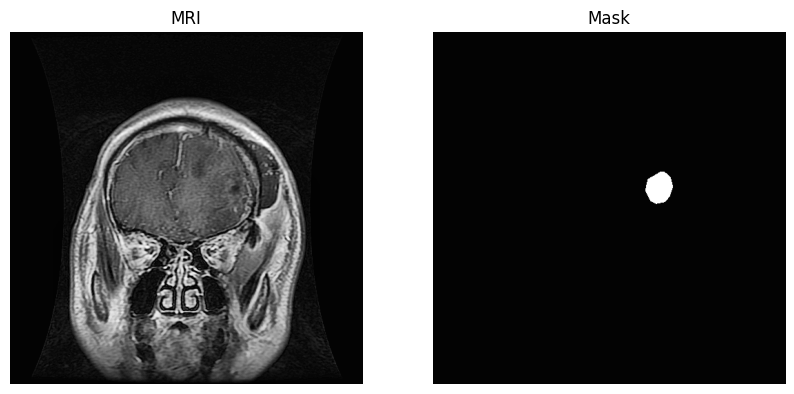

In [5]:
# showing samples

import cv2
import matplotlib.pyplot as plt
img = cv2.imread(path_frist_img_MRI)
img_MRI_RGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_mask = cv2.imread(path_frist_img_mask)

fig , axis = plt.subplots(1,2,figsize=(10,10))
axis[0].imshow(img_MRI_RGB);axis[0].set_title("MRI");axis[0].axis("off")
axis[1].imshow(img_mask);axis[1].set_title("Mask");axis[1].axis("off")
axis[1].imshow(img_mask)


In [6]:
from PIL import Image
import numpy as np
img = Image.open(path_frist_img_MRI)
print(img.size)

img_matrix = np.array(img)
print(img_matrix)
print(img_matrix.shape)

print(f'max Value in pexils is : {img_matrix.max()}')
print(f'min Value in pexils is : {img_matrix.min()})')
print(np.unique(img_matrix))


(512, 512)
[[3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 ...
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]]
(512, 512)
max Value in pexils is : 255
min Value in pexils is : 1)
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 19

In [7]:
img = Image.open(path_frist_img_mask)
print(img.size)

img_matrix = np.array(img)
print(img_matrix)
print(img_matrix.shape)

print(f'max Value in pexils is : {img_matrix.max()}')
print(f'min Value in pexils is : {img_matrix.min()})')
print(np.unique(img_matrix))

(512, 512)
[[3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 ...
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]]
(512, 512)
max Value in pexils is : 255
min Value in pexils is : 3)
[  3 255]


In [8]:
# num of pixels it represent Tumer in Mask image
count = 0
for row in img_matrix :
 for pixel in row :
  if pixel == 255 :
    count +=1
 perc = count / (512*512)
print(f'num of pixels it represent Tumer is : {count} from {512*512}')
print(f'the percentege of Tumer is {perc * 100 } %') # Imbalanced Dataset


num of pixels it represent Tumer is : 1383 from 262144
the percentege of Tumer is 0.5275726318359375 %


In [9]:
# calc mean of Tumer Pexils in Total pexils in Mask img

print("Glioma")
folder = path + "/DATASET/Segmentation/Glioma"

masks = []
files = os.listdir(folder)

for f in files:
    if "_mask" in f:
        masks.append(f)

print(f"Number of masks: {len(masks)}")

tumor_pixels = 0

for mask in masks:

    img = Image.open(os.path.join(folder, mask))
    img_matrix = np.array(img)

    for row in img_matrix:
        for pixel in row:
            if pixel == 255:
                tumor_pixels += 1

height, width = img_matrix.shape
total_pixels = height * width * len(masks)


tumor_percentage = (tumor_pixels / total_pixels) * 100

print(f"Total Pixels       : {total_pixels}")
print(f"Tumor Pixels       : {tumor_pixels}")
print(f"Tumor Percentage   : {tumor_percentage:.2f}%")



print("-----------------------------------------------------------------------")
print("Meningioma")

folder = path + "/DATASET/Segmentation/Meningioma"

masks = []
files = os.listdir(folder)

for f in files:
    if "_mask" in f:
        masks.append(f)

print(f"Number of masks: {len(masks)}")

tumor_pixels = 0

for mask in masks:

    img = Image.open(os.path.join(folder, mask))
    img_matrix = np.array(img)

    for row in img_matrix:
        for pixel in row:
            if pixel == 255:
                tumor_pixels += 1

height, width = img_matrix.shape
total_pixels = height * width * len(masks)


tumor_percentage = (tumor_pixels / total_pixels) * 100

print(f"Total Pixels       : {total_pixels}")
print(f"Tumor Pixels       : {tumor_pixels}")
print(f"Tumor Percentage   : {tumor_percentage:.2f}%")





print("-----------------------------------------------------------------------")
print("Pituitary tumor")

folder = path + "/DATASET/Segmentation/Pituitary tumor"

masks = []
files = os.listdir(folder)

for f in files:
    if "_mask" in f:
        masks.append(f)

print(f"Number of masks: {len(masks)}")

tumor_pixels = 0

for mask in masks:

    img = Image.open(os.path.join(folder, mask))
    img_matrix = np.array(img)

    for row in img_matrix:
        for pixel in row:
            if pixel == 255:
                tumor_pixels += 1

height, width = img_matrix.shape
total_pixels = height * width * len(masks)


tumor_percentage = (tumor_pixels / total_pixels) * 100

print(f"Total Pixels       : {total_pixels}")
print(f"Tumor Pixels       : {tumor_pixels}")
print(f"Tumor Percentage   : {tumor_percentage:.2f}%")

# Clean Memory
del masks
gc.collect()





Glioma
Number of masks: 554
Total Pixels       : 145227776
Tumor Pixels       : 2691837
Tumor Percentage   : 1.85%
-----------------------------------------------------------------------
Meningioma
Number of masks: 708
Total Pixels       : 185597952
Tumor Pixels       : 4020087
Tumor Percentage   : 2.17%
-----------------------------------------------------------------------
Pituitary tumor
Number of masks: 930
Total Pixels       : 243793920
Tumor Pixels       : 2754896
Tumor Percentage   : 1.13%


51

In [10]:
# check if any mask is Empty
import gc


print("---------------------------------------------------------------")
print("Pituitary tumor")
empty_masks = []
folder = path + "/DATASET/Segmentation/Pituitary tumor"
files = os.listdir(folder)

for f in files:
    if "_mask" in f:
        img = Image.open(os.path.join(folder, f))
        img_matrix = np.array(img)
        found = False

        for row in img_matrix:
            for pixel in row:
                if pixel == 255:
                    found = True
                    break
            if found:
                break

        if not found:
            empty_masks.append(f)

print(f'num of empty masks is : {len(empty_masks)}')


print("---------------------------------------------------------------")
print("Glioma")
empty_masks = []
folder = path + "/DATASET/Segmentation/Glioma"
files = os.listdir(folder)

for f in files:
    if "_mask" in f:
        img = Image.open(os.path.join(folder, f))
        img_matrix = np.array(img)
        found = False

        for row in img_matrix:
            for pixel in row:
                if pixel == 255:
                    found = True
                    break
            if found:
                break

        if not found:
            empty_masks.append(f)

print(f'num of empty masks is : {len(empty_masks)}')


print("---------------------------------------------------------------")
print("Meningioma")
empty_masks = []
folder = path + "/DATASET/Segmentation/Meningioma"
files = os.listdir(folder)

for f in files:
    if "_mask" in f:
        img = Image.open(os.path.join(folder, f))
        img_matrix = np.array(img)
        found = False

        for row in img_matrix:
            for pixel in row:
                if pixel == 255:
                    found = True
                    break
            if found:
                break

        if not found:
            empty_masks.append(f)

print(f'num of empty masks is : {len(empty_masks)}')


# clean Memory
del empty_masks
gc.collect()





---------------------------------------------------------------
Pituitary tumor
num of empty masks is : 0
---------------------------------------------------------------
Glioma
num of empty masks is : 0
---------------------------------------------------------------
Meningioma
num of empty masks is : 0


0

In [11]:
# Check if any image have one mask or not have ?

# Meningioma
folder = path + "/DATASET/Segmentation/Meningioma"
files = os.listdir(folder)

img_MRI ={ f.replace(".png","")  for f in files if f.endswith('.png') and "_mask" not in f }
img_mask ={f.replace("_mask","") for f in files if "_mask" in f}

num_MRI = len(img_MRI)
num_mask = len(img_mask)

print(f' num of differnce between MRI and Mask in Meningioma is  :  {int(num_mask - num_MRI)}')


# Glioma
folder = path + "/DATASET/Segmentation/Glioma"
files = os.listdir(folder)

img_MRI ={ f.replace(".png","")  for f in files if f.endswith('.png') and "_mask" not in f }
img_mask ={f.replace("_mask","") for f in files if "_mask" in f}

num_MRI = len(img_MRI)
num_mask = len(img_mask)


print(f' num of differnce between MRI and Mask in Glioma is  :  {int(num_mask - num_MRI)}')



# Pituitary tumor
folder = path + "/DATASET/Segmentation/Pituitary tumor"
files = os.listdir(folder)

img_MRI ={ f.replace(".png","")  for f in files if f.endswith('.png') and "_mask" not in f }
img_mask ={f.replace("_mask","") for f in files if "_mask" in f}

num_MRI = len(img_MRI)
num_mask = len(img_mask)

print(f' num of differnce between MRI and Mask in Pituitary tumor is  :  {int(num_mask - num_MRI)}')


# Clean Memory
del img_MRI
del img_mask
del num_MRI
del num_mask
gc.collect()



 num of differnce between MRI and Mask in Meningioma is  :  0
 num of differnce between MRI and Mask in Glioma is  :  0
 num of differnce between MRI and Mask in Pituitary tumor is  :  0


0

In [12]:
# Results of EDA :-
# the images is Gray Scale and it size is (512, 512)
# the values in pexils is between 1 - 255
# Imbalanced Dataset , so do not use Accuracy here
# in image masks represent Pexiles in Range 3 -> 255
# in image MRI  represent Pexiles in Range 1 -> 255
# Not Empty masks

In [2]:
# Train / Validation / Test Split

import gc
import os
import random
from sklearn.model_selection import train_test_split

random.seed(42)


# Glioma
folder = os.path.join(path, "DATASET", "Segmentation", "Glioma")
files = os.listdir(folder)

images_Glioma = sorted([
    os.path.join(folder, f)
    for f in files
    if f.endswith(".png") and "_mask" not in f
])

masks_Glioma = sorted([
    os.path.join(folder, f)
    for f in files
    if f.endswith(".png") and "_mask" in f
])


# Meningioma
folder = os.path.join(path, "DATASET", "Segmentation", "Meningioma")
files = os.listdir(folder)

images_Meningioma = sorted([
    os.path.join(folder, f)
    for f in files
    if f.endswith(".png") and "_mask" not in f
])

masks_Meningioma = sorted([
    os.path.join(folder, f)
    for f in files
    if f.endswith(".png") and "_mask" in f
])


# Pituitary Tumor
folder = os.path.join(path, "DATASET", "Segmentation", "Pituitary tumor")
files = os.listdir(folder)

images_Pituitary = sorted([
    os.path.join(folder, f)
    for f in files
    if f.endswith(".png") and "_mask" not in f
])

masks_Pituitary = sorted([
    os.path.join(folder, f)
    for f in files
    if f.endswith(".png") and "_mask" in f
])


# Check
print("Glioma :", len(images_Glioma), len(masks_Glioma))
print("Meningioma :", len(images_Meningioma), len(masks_Meningioma))
print("Pituitary :", len(images_Pituitary), len(masks_Pituitary))



# Pair Images with Masks
Glioma_Data = list(zip(images_Glioma, masks_Glioma))
Meningioma_Data = list(zip(images_Meningioma, masks_Meningioma))
Pituitary_Data = list(zip(images_Pituitary, masks_Pituitary))


# Split Glioma
Glioma_Train, Glioma_Temp = train_test_split(
    Glioma_Data,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

Glioma_Val, Glioma_Test = train_test_split(
    Glioma_Temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)


# Split Meningioma
Meningioma_Train, Meningioma_Temp = train_test_split(
    Meningioma_Data,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

Meningioma_Val, Meningioma_Test = train_test_split(
    Meningioma_Temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)


# Split Pituitary
Pituitary_Train, Pituitary_Temp = train_test_split(
    Pituitary_Data,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

Pituitary_Val, Pituitary_Test = train_test_split(
    Pituitary_Temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)


# Merge
Train_data = (
    Glioma_Train +
    Meningioma_Train +
    Pituitary_Train
)

Val_data = (
    Glioma_Val +
    Meningioma_Val +
    Pituitary_Val
)

Test_data = (
    Glioma_Test +
    Meningioma_Test +
    Pituitary_Test
)

random.shuffle(Train_data)
random.shuffle(Val_data)
random.shuffle(Test_data)


# Check
print("\nTrain :", len(Train_data))
print("Validation :", len(Val_data))
print("Test :", len(Test_data))

Glioma : 554 554
Meningioma : 708 708
Pituitary : 930 930

Train : 1533
Validation : 328
Test : 331


In [3]:
# Normlization

import cv2
import numpy as np
import gc


# MRI Images

Trian_MRI = []
for img_path, _ in Train_data:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0

    Trian_MRI.append(img)



Test_MRI = []

for img_path, _ in Test_data:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0

    Test_MRI.append(img)


Val_MRI = []

for img_path, _ in Val_data:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0

    Val_MRI.append(img)




# Masks are not normalized.
# We perform Label Encoding (Remapping):
# 3 -> 0 (Background)
# 255 -> 1 (Tumor)


# Masks

Train_Mask = []

for _, mask_path in Train_data:

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(
        mask,
        (256,256),
        interpolation=cv2.INTER_NEAREST
    )

    mask = (mask > 127).astype(np.uint8)

    Train_Mask.append(mask)



Test_Mask = []

for _, mask_path in Test_data:

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(
        mask,
        (256,256),
        interpolation=cv2.INTER_NEAREST
    )

    mask = (mask > 127).astype(np.uint8)

    Test_Mask.append(mask)



Val_Mask = []

for _, mask_path in Val_data:

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(
        mask,
        (256,256),
        interpolation=cv2.INTER_NEAREST
    )

    mask = (mask > 127).astype(np.uint8)

    Val_Mask.append(mask)


# Check


print(np.unique(np.array(Train_Mask)))
print(np.unique(np.array(Test_Mask)))
print(np.unique(np.array(Val_Mask)))

print("--------------------------------")

print(Trian_MRI[0].shape)
print(Train_Mask[0].shape)



# Pair MRI with Masks
Train_Data = list(zip(Trian_MRI, Train_Mask))
Test_Data = list(zip(Test_MRI, Test_Mask))
Val_Data = list(zip(Val_MRI, Val_Mask))


# Memory Cleaning
del Train_data
del Test_data
del Val_data

gc.collect()

[0 1]
[0 1]
[0 1]
--------------------------------
(256, 256)
(256, 256)


0

In [4]:
# Data Augmentation


import gc

MRI_AUG = []
Mask_AUG = []

for img, mask in Train_Data:

    h, w = img.shape



    MRI_AUG.append(img)
    Mask_AUG.append(mask)


    angle = np.random.randint(-15, 16)

    M = cv2.getRotationMatrix2D(
        (w // 2, h // 2),
        angle,
        1
    )

    rotate_img = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    rotate_mask = cv2.warpAffine(
        mask,
        M,
        (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    MRI_AUG.append(rotate_img.astype(np.float32))
    Mask_AUG.append(rotate_mask.astype(np.uint8))



    tx = np.random.randint(-20, 21)
    ty = np.random.randint(-20, 21)

    M = np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

    shift_img = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    shift_mask = cv2.warpAffine(
        mask,
        M,
        (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    MRI_AUG.append(shift_img.astype(np.float32))
    Mask_AUG.append(shift_mask.astype(np.uint8))



    bright = np.clip(img + 0.10, 0, 1)

    MRI_AUG.append(bright.astype(np.float32))
    Mask_AUG.append(mask)



    contrast = np.clip(img * 1.10, 0, 1)

    MRI_AUG.append(contrast.astype(np.float32))
    Mask_AUG.append(mask)

print("Original :", len(Train_Data))
print("Augmented :", len(MRI_AUG))


# Convert to NumPy


X_train = np.array(MRI_AUG, dtype=np.float32)
Y_train = np.array(Mask_AUG, dtype=np.uint8)

X_test = np.array(Test_MRI, dtype=np.float32)
Y_test = np.array(Test_Mask, dtype=np.uint8)

X_Val = np.array(Val_MRI, dtype=np.float32)
Y_Val = np.array(Val_Mask, dtype=np.uint8)


# Free Memory


del MRI_AUG
del Mask_AUG
del Train_Data

del Trian_MRI
del Train_Mask

del Test_MRI
del Test_Mask

del Val_MRI
del Val_Mask

gc.collect()


# Add Channel Dimension


X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
X_Val = X_Val[..., np.newaxis]

Y_train = Y_train[..., np.newaxis]
Y_test = Y_test[..., np.newaxis]
Y_Val = Y_Val[..., np.newaxis]


# Convert value of Chanal to 3
X_train = np.repeat(X_train, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)
X_Val = np.repeat(X_Val, 3, axis=-1)

# Check


print("X_train :", X_train.shape, X_train.dtype)
print("Y_train :", Y_train.shape, Y_train.dtype)

print("X_test  :", X_test.shape, X_test.dtype)
print("Y_test  :", Y_test.shape, Y_test.dtype)

print("X_Val   :", X_Val.shape, X_Val.dtype)
print("Y_Val   :", Y_Val.shape, Y_Val.dtype)

print("Mask Labels :", np.unique(Y_train))

Original : 1533
Augmented : 7665
X_train : (7665, 256, 256, 3) float32
Y_train : (7665, 256, 256, 1) uint8
X_test  : (331, 256, 256, 3) float32
Y_test  : (331, 256, 256, 1) uint8
X_Val   : (328, 256, 256, 3) float32
Y_Val   : (328, 256, 256, 1) uint8
Mask Labels : [0 1]


In [16]:
# check values in Pexil of Data

print(f'Rnage of  Values in X_train is {np.min(X_train)} -> {np.max(X_train)}')
print(f'Rnage of Values in Y_train is {np.min(Y_train)} -> {np.max(Y_train)}')

print(f'Rnage of Values in X_test is {np.min(X_test)} -> {np.max(X_test)}')
print(f'Rnage of Values in Y_test is {np.min(Y_test)} -> {np.max(Y_test)}')

print(f'Rnage of Values in X_Val is {np.min(X_Val)} -> {np.max(X_Val)}')
print(f'Rnage of Values in Y_Val is {np.min(Y_Val)} -> {np.max(Y_Val)}')




Rnage of  Values in X_train is 0.0 -> 1.0
Rnage of Values in Y_train is 0 -> 1
Rnage of Values in X_test is 0.0 -> 1.0
Rnage of Values in Y_test is 0 -> 1
Rnage of Values in X_Val is 0.0 -> 1.0
Rnage of Values in Y_Val is 0 -> 1


In [17]:
# check nume of Samples

print(len(X_train), len(Y_train))
print(len(X_test), len(Y_test))
print(len(X_Val), len(Y_Val))

7665 7665
331 331
328 328


In [5]:
# Convert Type of Masks  to Float32 T use U-NET

Y_train = Y_train.astype(np.float32)
Y_test = Y_test.astype(np.float32)
Y_Val = Y_Val.astype(np.float32)

In [ ]:
# Check Sixe of Data

print(X_train.shape)
print(Y_train.shape)

print(X_train.dtype)
print(Y_train.dtype)

print(np.unique(Y_train))

(7665, 256, 256, 3)
(7665, 256, 256, 1)
float32
float32


In [ ]:
print(X_train.shape)

In [ ]:
# Convert value of Chanal to 3
X_train = np.repeat(X_train, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)
X_Val = np.repeat(X_Val, 3, axis=-1)


In [ ]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

import segmentation_models as sm

BACKBONE = "resnet34" # Encoder = resnet34

preprocess_input = sm.get_preprocessing(BACKBONE) # Prerocessing Train - Validation  - Test

# preprcessing input Data on resnet34
X_train = preprocess_input(X_train)
X_test = preprocess_input(X_test)
X_Val = preprocess_input(X_Val)

model = sm.Unet(
    BACKBONE,
    classes=1,  # Classes = 1 becouse Mask have Two Values 0 -> Background , 1 -> Tumer so it is Binary Sigmentation .
    encoder_weights="imagenet",
    activation="sigmoid"
)

model.compile(
    optimizer="Adam",
    loss=sm.losses.bce_jaccard_loss,
    metrics=[sm.metrics.iou_score]
)

history = model.fit(
    X_train,
    Y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_Val, Y_Val)
)

In [ ]:
import segmentation_models as sm

BACKBONE = 'resnet34'  # Encoder = resnet34

preprocess_input = sm.get_preprocessing(BACKBONE) # Prerocessing Train - Validation  - Test

# preprcessing input Data on resnet34
X_train = preprocess_input(X_train)
X_test = preprocess_input(X_test)
X_Val = preprocess_input(X_Val)



model = sm.Unet(BACKBONE, classes = 1  ,encoder_weights='imagenet' , activation='sigmoid' ) # Classes = 1 becouse Mask have Two Values 0 -> Background , 1 -> Tumer so it is Binary Sigmentation .

model.compile(
       'Adam',
    loss=sm.losses.bce_jaccard_loss,
    metrics=[sm.metrics.iou_score],
)

model.fit(
    X_train,
    Y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_Val, Y_Val),
)







